# Autoimmune cloud  The cellular automaton

**The model's primary formulation.** A platform of service instances laid out on
a 2D lattice, each following one local transition rule, updated synchronously.

This notebook does three things:

1. states the model as a **cellular automaton** and shows the rule operating
2. validates it against **two exact analytic predictions**, one for each of the
   two ways a cell can be removed
3. demonstrates the project's central claim that an automated remediation
   system has a sensitivity threshold past which it destroys more of the
   platform than the faults it is defending against

---

## 1. The system

A platform runs many instances of a service. Each carries some share of the
traffic and has finite capacity. When an instance is removed, **its traffic does
not vanish** it lands on the instances next to it, which may push them past
their own limits. That is a load-redistribution cascade, the same mechanism as a
power-grid blackout.

Nobody watches hundreds of instances by hand, so platforms deploy anomaly
detection with **automated** response: anything whose telemetry looks wrong is
quarantined and killed, with no human in the loop.

Every statistical detector has an unavoidable error rate, because the telemetry
of a genuinely faulty instance and that of a merely busy one overlap. In a
monitored system a false positive costs an engineer's attention. In an automated
system it **removes a healthy instance** and removing a loaded instance sheds
its traffic onto its neighbours, which makes *them* look busy, which trips the
detector again.

```
false positive -> instance quarantined -> its load spills onto neighbours
      ^                                                    |
      |                                                    v
   detector flags them  <-  neighbours' utilisation rises
```

The remediation system is a cascade process running on the same substrate it is
supposed to protect. The biological parallel is autoimmunity: a more aggressive
immune response clears pathogens faster, but past a point it destroys healthy
tissue, and the optimal response is not the most aggressive one.

## 2. The model as a cellular automaton

| CA component | In this model |
|---|---|
| **Cells** | a $W \times H$ lattice; each cell is one service instance |
| **States** | `HEALTHY`, `DEGRADED`, `SHEDDING`, `DOWN`, `QUARANTINING`, `QUARANTINED` |
| **Neighbourhood** | von Neumann (4) or Moore (8) identical for every cell |
| **Rule** | one transition function, applied uniformly to every cell |
| **Update** | synchronous: the whole lattice advances from $t$ to $t+1$ using only the configuration at $t$ |
| **Boundary** | fixed, non-periodic edge cells simply have fewer neighbours |

Each cell also carries a real-valued **load**. That is standard for CA used to
model transport: the sandpile CA carries a grain count and the forest-fire CA
carries a tree state in exactly the same way. Load moves only between lattice
neighbours, so the rule stays strictly local.

### The transition rule

For cell $i$ with neighbourhood $N(i)$:

**Step 1 gather.** A cell that failed on the previous step spills its traffic
evenly across its own neighbourhood:

$$\text{incoming}_i = \sum_{j \,\in\, N(i),\; s_j \in \{\text{SHEDDING},\, \text{QUARANTINING}\}} \frac{\ell_j}{|N(j)|}$$

$$\ell_i(t{+}1) = \ell_i(t) + \text{incoming}_i$$

**Step 2 transition.**

| from | to | when |
|---|---|---|
| `SHEDDING` | `DOWN` | always (it has now spilled; load set to 0) |
| `QUARANTINING` | `QUARANTINED` | always (load set to 0) |
| `DOWN`, `QUARANTINED` | unchanged | absorbing |
| `HEALTHY` | `DEGRADED` | with probability $p$ — a fault appears |
| `HEALTHY`/`DEGRADED` | `SHEDDING` | $\ell_i(t{+}1) > c_i$ — genuine overload |
| `HEALTHY`/`DEGRADED` | `QUARANTINING` | else if $\text{telemetry}_i > \theta$ |

`SHEDDING` and `QUARANTINING` are **one-step transient states**, exactly as
`BURNING` is in the forest-fire CA. They exist so a cell's load can be handed to
its neighbours on the following step using only local information.

Keeping `DOWN` and `QUARANTINED` as separate absorbing states is deliberate: one
means the cell genuinely ran out of capacity, the other means an automated
detector removed a cell that was still within capacity. That distinction is what
lets damage be attributed to overload versus to the remediation system itself.

### Telemetry

$$\text{telemetry}_i = \frac{\ell_i}{c_i} \;+\; \delta \cdot \mathbb{1}[s_i = \text{DEGRADED}] \;+\; \varepsilon_i,
\qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2)$$

Utilisation, plus an offset if the cell is genuinely faulty, plus noise. The
noise is what makes the faulty and busy populations **overlap**, so no threshold
separates them cleanly. That overlap is not a modelling convenience — it is the
reason the problem exists.

Capacity is provisioned from the intact load, $c_i = (1+\alpha)\,\ell_i(0)$,
so $\alpha$ is spare capacity.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
sys.path.insert(0, os.path.abspath("../utils"))

import numpy as np
import matplotlib.pyplot as plt

from lattice import (LatticeCA, run_trial, run_episode, sweep_theta,
                     HEALTHY, DEGRADED, SHEDDING, DOWN,
                     QUARANTINING, QUARANTINED, STATE_NAMES)
from plotting import (use_house_style, show_lattice, lattice_strip,
                      damage_decomposition, mark_minimum, COLOURS)
from metrics import susceptibility, critical_point, bimodality, describe_tail

use_house_style()
SEED = 42
print("states:", {v: k for k, v in STATE_NAMES.items()})

states: {'healthy': 0, 'shedding': 1, 'down': 2, 'quarantining': 3, 'quarantined': 4, 'degraded': 5}


### The rule, operating

A small lattice, one cell removed at the centre, stepped by hand. Watch the
spilled load appear on the four neighbours.

In [2]:
ca = LatticeCA(width=7, height=7, alpha=0.3, seed=SEED)
print("neighbour counts |N(i)| (fewer at edges: the lattice does not wrap)")
print(ca.degree.astype(int))

print(f"\ntotal load at t=0: {ca.load.sum():.3f}")
y, x = ca.seed_failure()
print(f"removed the centre cell ({y}, {x}), which carried {ca.load[y, x]:.3f}")

ca.step()
print(f"total load at t=1: {ca.load.sum():.3f}   <- conserved, not destroyed")
print("\nload after one step (centre emptied, 4 neighbours each +0.25):")
print(np.round(ca.load, 3))

neighbour counts |N(i)| (fewer at edges: the lattice does not wrap)
[[2 3 3 3 3 3 2]
 [3 4 4 4 4 4 3]
 [3 4 4 4 4 4 3]
 [3 4 4 4 4 4 3]
 [3 4 4 4 4 4 3]
 [3 4 4 4 4 4 3]
 [2 3 3 3 3 3 2]]

total load at t=0: 49.000
removed the centre cell (3, 3), which carried 1.000
total load at t=1: 49.000   <- conserved, not destroyed

load after one step (centre emptied, 4 neighbours each +0.25):
[[1.   1.   1.   1.   1.   1.   1.  ]
 [1.   1.   1.   1.   1.   1.   1.  ]
 [1.   1.   1.   1.25 1.   1.   1.  ]
 [1.   1.   1.25 0.   1.25 1.   1.  ]
 [1.   1.   1.   1.25 1.   1.   1.  ]
 [1.   1.   1.   1.   1.   1.   1.  ]
 [1.   1.   1.   1.   1.   1.   1.  ]]


Load is **conserved** by the redistribution step the removed cell's traffic
is transferred, not deleted. That is the single most important property to get
right, because a cascade is precisely the consequence of traffic having to go
somewhere.

## 3. Validation gate 1 the overload threshold

The critical spare capacity can be derived exactly, before running anything.

A cell fails and spills $\ell/|N|$ to each neighbour, so a neighbour goes from
$\ell$ to $\ell\,(1 + 1/|N|)$. The cascade stops if and only if that still
fits inside capacity:

$$\ell\left(1 + \tfrac{1}{|N|}\right) \le (1+\alpha)\,\ell
\qquad\Longleftrightarrow\qquad
\boxed{\;\alpha_c = \frac{1}{|N|}\;}$$

A von Neumann lattice needs 25% headroom to absorb a single failure; a Moore
lattice only 12.5%, because the load spreads across twice as many cells.

This is a sharp falsifiable prediction, and a much stronger gate than "we
observe a transition".

In [3]:
print(f"{'neighbourhood':>14}{'|N|':>5}{'predicted':>11}{'measured':>10}{'error':>9}")
print("-" * 49)

gate1 = []
for nb, deg in (("von_neumann", 4), ("moore", 8)):
    predicted = 1.0 / deg
    measured = np.nan
    for a in np.linspace(0.01, 0.40, 391):
        if run_trial(a, 41, 41, neighbourhood=nb,
                     load_sigma=0.0, seed=1)["removed"] <= 1:
            measured = a
            break
    gate1.append((nb, predicted, measured))
    print(f"{nb:>14}{deg:>5}{predicted:>11.4f}{measured:>10.4f}"
          f"{abs(measured - predicted):>9.4f}")

assert all(abs(m - p) < 0.005 for _, p, m in gate1)
print("\n[GATE 1 PASSED] measured overload threshold matches 1/|N|")

 neighbourhood  |N|  predicted  measured    error
-------------------------------------------------


   von_neumann    4     0.2500    0.2500   0.0000


         moore    8     0.1250    0.1250   0.0000

[GATE 1 PASSED] measured overload threshold matches 1/|N|


## 4. Validation gate 2 the detector threshold

The detector gives a cell a *second* way to be removed, and that route has its
own critical point.

A healthy cell sitting at baseline reads $\frac{1}{1+\alpha}$. Once one
neighbour dies it reads

$$\frac{1 + 1/|N|}{1 + \alpha}$$

If the threshold is below that value, then **every cell that absorbs a dead
neighbour is immediately flagged** and quarantining it spills more load onto
*its* neighbours, which are then flagged in turn. The cascade becomes
self-sustaining:

$$\boxed{\;\theta_c = \frac{1 + 1/|N|}{1 + \alpha}\;}$$

Two things follow immediately, and they are the analytic core of this project.

**The critical sensitivity depends on spare capacity.** More headroom lowers
$\theta_c$, so a better-provisioned platform can safely run a more aggressive
detector. Detector accuracy does not appear in the expression at all.

**It depends on the neighbourhood.** A larger $|N|$ spreads the spilled load
thinner, so each neighbour rises less and a lower threshold is tolerable.

In [4]:
print(f"{'nbhd':>12}{'|N|':>4}{'alpha':>7}{'predicted':>11}{'measured':>10}{'error':>9}")
print("-" * 53)

gate2 = []
for nb, deg in (("von_neumann", 4), ("moore", 8)):
    for alpha in (0.4, 0.6, 0.8, 1.0):
        predicted = (1 + 1 / deg) / (1 + alpha)
        measured = np.nan
        for th in np.arange(predicted + 0.06, 0.0, -0.002):
            if run_trial(alpha, 50, 50, neighbourhood=nb, theta=th,
                         noise=0.0, load_sigma=0.0,
                         seed=5)["removed_fraction"] > 0.5:
                measured = th
                break
        gate2.append((predicted, measured))
        print(f"{nb:>12}{deg:>4}{alpha:>7.2f}{predicted:>11.4f}"
              f"{measured:>10.4f}{abs(measured - predicted):>9.4f}")

assert all(abs(m - p) < 0.01 for p, m in gate2)
print("\n[GATE 2 PASSED] measured detector threshold matches (1 + 1/|N|)/(1 + alpha)")

        nbhd |N|  alpha  predicted  measured    error
-----------------------------------------------------
 von_neumann   4   0.40     0.8929    0.8929   0.0000
 von_neumann   4   0.60     0.7812    0.7792   0.0020
 von_neumann   4   0.80     0.6944    0.6924   0.0020
 von_neumann   4   1.00     0.6250    0.6230   0.0020
       moore   8   0.40     0.8036    0.8016   0.0020
       moore   8   0.60     0.7031    0.7011   0.0020


       moore   8   0.80     0.6250    0.6230   0.0020
       moore   8   1.00     0.5625    0.5605   0.0020

[GATE 2 PASSED] measured detector threshold matches (1 + 1/|N|)/(1 + alpha)


## 5. The headline result

Now the experiment the project exists to run.

Set spare capacity to $\alpha = 0.6$. The overload threshold is
$\alpha_c = 0.25$, so the platform is **comfortably subcritical**: with the
detector switched off, removing a cell does nothing at all. A physical cascade
is impossible here.

Then switch the detector on.

In [5]:
alpha = 0.6
theta_c = (1 + 1 / 4) / (1 + alpha)
print(f"alpha = {alpha}   (overload threshold alpha_c = 0.25, so subcritical)")
print(f"theta_c = {theta_c:.3f}\n")

print(f"{'detector':>12}{'removed':>10}{'by overload':>13}{'by detector':>13}{'steps':>7}")
print("-" * 55)
for th in (np.inf, 0.90, 0.85, 0.80, 0.78, 0.70):
    r = run_trial(alpha, 60, 60, theta=th, noise=0.02, load_sigma=0.0, seed=3, steps=150)
    label = "off" if not np.isfinite(th) else f"theta={th:.2f}"
    print(f"{label:>12}{r['removed_fraction']:>10.4f}{r['overload']:>13}"
          f"{r['quarantined']:>13}{r['steps']:>7}")

alpha = 0.6   (overload threshold alpha_c = 0.25, so subcritical)
theta_c = 0.781

    detector   removed  by overload  by detector  steps
-------------------------------------------------------
         off    0.0003            1            0    150
  theta=0.90    0.0003            1            0    150
  theta=0.85    0.0003            1            0    150
  theta=0.80    1.0000         3342          258    150


  theta=0.78    1.0000         3421          179    150
  theta=0.70    1.0000         3272          328    150


**With the detector off, one cell is lost and nothing follows.** With the
detector on and $\theta$ below $\theta_c$, the entire lattice is destroyed
in a regime where the physical cascade cannot propagate at all.

Every one of those losses is self-inflicted. There was no external shock beyond
the single seeded cell, and the platform had more than twice the headroom needed
to absorb it.

Note also what the damage is made of. Most cells are recorded as lost to
*overload*, not to the detector directly but they only overloaded because the
detector had already removed enough of their neighbours to push the load onto
them. The detector is the cause even where it is not the proximate mechanism.

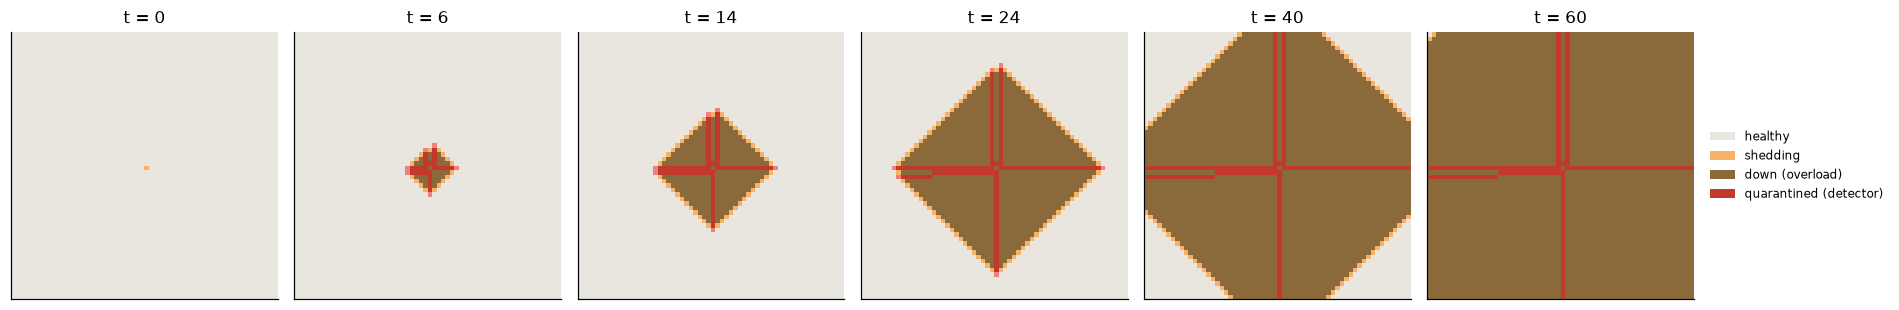

In [6]:
# the same cascade, watched as it spreads
ca = LatticeCA(width=60, height=60, alpha=alpha, theta=0.78,
               noise=0.02, load_sigma=0.0, seed=3)
ca.seed_failure()
snaps, shots = [ca.state.copy()], [0]
for step in range(1, 61):
    ca.step()
    if step in (6, 14, 24, 40, 60):
        snaps.append(ca.state.copy())
        shots.append(step)

fig, axes = lattice_strip(snaps, titles=[f"t = {s}" for s in shots])
show_lattice(snaps[-1], ax=axes[-1], title=f"t = {shots[-1]}", legend=True)
plt.show()

The cascade spreads as a front from the single seeded cell. Violet is absent
because no faults were injected in this run every cell shown as lost was
healthy and within capacity when the run began.

The two colours tell the story: red cells were removed directly by the detector,
brown cells overloaded once their neighbours had gone. The front advances
because each removal loads the ring around it.

## 6. Why it is all-or-nothing

The lattice transition is **bimodal**: cascades either die immediately or
consume everything, with very little in between. That is worth measuring rather
than asserting, because it is a qualitative property of this topology and it is
one of the things that changes when the lattice is replaced by a dependency
graph in notebook 02.

300 trials at alpha = 0.30 (near the smeared transition)

  negligible   (<2% of lattice) : 47.7%
  intermediate (2-90%)          : 0.0%
  near-total   (>90%)           : 52.3%

  sizes: n=205  median=2499  mean=1914.6  max=2500  mean/median=0.8
         MLE power law: alpha=1.17, xmin=2, n_tail=205, KS=0.470
         vs exponential: R=-84.2, p=0.035 (inconclusive)


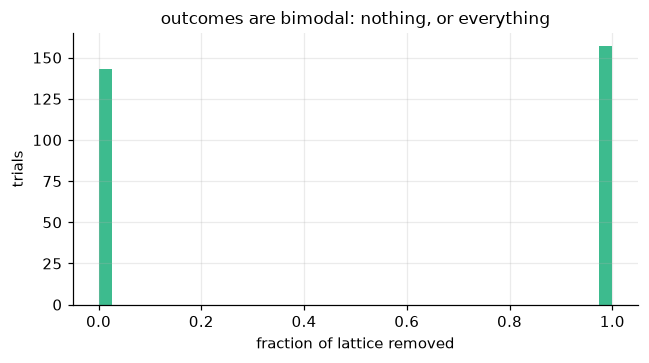

In [7]:
sizes = np.array([run_trial(0.30, 50, 50, load_sigma=0.5,
                            seed=s)["removed"] for s in range(300)])
b = bimodality(sizes, total=50 * 50)

print(f"300 trials at alpha = 0.30 (near the smeared transition)\n")
print(f"  negligible   (<2% of lattice) : {b['frac_negligible']:.1%}")
print(f"  intermediate (2-90%)          : {b['frac_intermediate']:.1%}")
print(f"  near-total   (>90%)           : {b['frac_total']:.1%}")
print()
print(describe_tail(sizes[sizes > 1], label="  sizes: "))

fig, ax = plt.subplots(figsize=(6.0, 3.4))
ax.hist(sizes / (50 * 50), bins=40, color=COLOURS["lattice"], alpha=0.85)
ax.set_xlabel("fraction of lattice removed")
ax.set_ylabel("trials")
ax.set_title("outcomes are bimodal: nothing, or everything")
plt.tight_layout(); plt.show()

A uniform lattice gives every cell the same number of neighbours and the same
share of the load, so once a cascade is self-sustaining anywhere it is
self-sustaining everywhere. There is no structure for it to stop against.

Keep this in mind for notebook 02: on a **dependency graph**, where some
services are called by far more things than others, the same rules produce
avalanches of every size instead. The topology, not the rule, decides the
character of the transition.

## 7. The U-curve

So far the detector has only been a liability, which makes the optimal setting
trivially "switch it off". That is not the real trade-off, because real
platforms do develop faults, and an undetected fault has an ongoing cost.

Each healthy cell now becomes `DEGRADED` with probability $p$ per step. A
degraded cell keeps serving but is faulty, reads higher on telemetry (by
$\delta$), and costs something for every step it goes unremediated. The
detector can catch it but the same threshold that catches faults also removes
healthy cells.

Damage is accumulated over an episode and split three ways:

| Source | Meaning |
|---|---|
| **unremediated** | cell-steps spent degraded and undetected |
| **overload** | cells that genuinely exceeded capacity |
| **false positive** | healthy, within-capacity cells the detector removed |

Reporting only the total would show a U-shape but not explain it. Split three
ways, the two arms have visibly different causes.

In [8]:
alpha = 0.6
base = 1 / (1 + alpha)
print("where the telemetry values sit at alpha = 0.6:")
print(f"  healthy, baseline           {base:.3f}")
print(f"  healthy, one dead neighbour {(1 + 1/4) / (1 + alpha):.3f}   <- theta_c")
print(f"  healthy, two dead neighbours{(1 + 2/4) / (1 + alpha):.3f}")
print(f"  degraded (fault signal +0.35){base + 0.35:.3f}")

thetas = np.arange(0.70, 1.22, 0.02)
res = sweep_theta(thetas, alpha=alpha, replicates=8, steps=150,
                  width=50, height=50, noise=0.03, fault_rate=2e-4, seed=1)
i = int(np.argmin(res["total_damage"]))
print(f"\nminimum total damage {res['total_damage'][i]:.3f} "
      f"at theta = {thetas[i]:.2f}")

where the telemetry values sit at alpha = 0.6:
  healthy, baseline           0.625
  healthy, one dead neighbour 0.781   <- theta_c
  healthy, two dead neighbours0.938
  degraded (fault signal +0.35)0.975



minimum total damage 0.162 at theta = 1.00


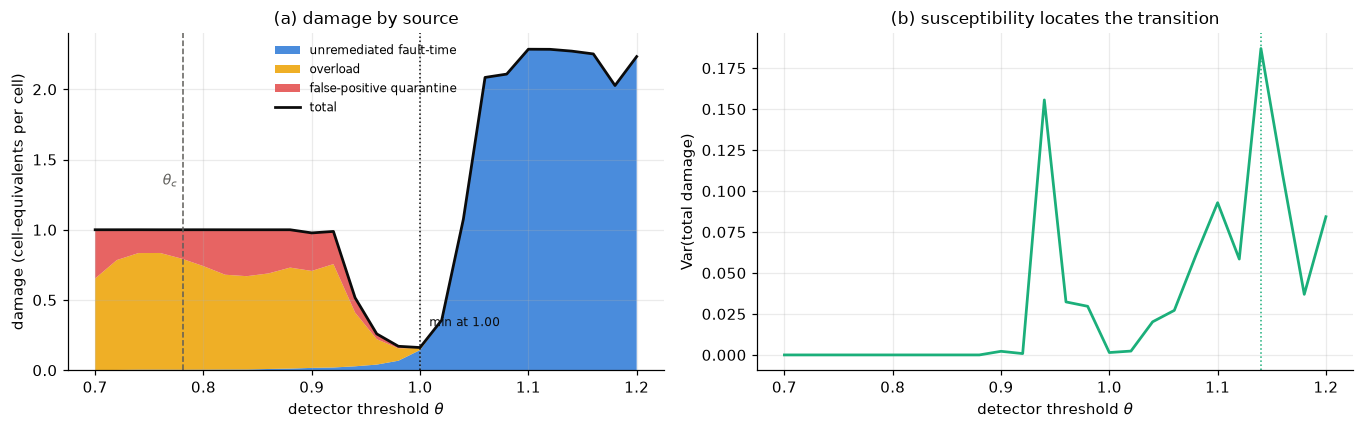

susceptibility peak at theta = 1.14


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))

ax = axes[0]
damage_decomposition(ax, thetas,
                     [res["unremediated"], res["overload"],
                      res["false_positive"]])
ax.plot(thetas, res["total_damage"], color=COLOURS["total"], lw=1.8,
        label="total")
mark_minimum(ax, thetas, res["total_damage"])
ax.axvline(theta_c, color="#5f5e5a", ls="--", lw=1)
ax.text(theta_c - 0.005, ax.get_ylim()[1] * 0.55, r"$\theta_c$",
        ha="right", fontsize=9, color="#5f5e5a")
ax.set_title("(a) damage by source")
ax.legend(fontsize=8, loc="upper center")

ax = axes[1]
ax.plot(thetas, res["susceptibility"], color=COLOURS["lattice"], lw=1.8)
ax.axvline(thetas[int(np.argmax(res["susceptibility"]))],
           color=COLOURS["lattice"], ls=":", lw=1)
ax.set_xlabel(r"detector threshold $\theta$")
ax.set_ylabel("Var(total damage)")
ax.set_title("(b) susceptibility locates the transition")

plt.tight_layout(); plt.show()

print(f"susceptibility peak at theta = "
      f"{critical_point(thetas, res['susceptibility']):.2f}")

**Reading the figure.**

Note that $\theta$ increases to the right, so **the detector gets *less*
sensitive as you move right**. The U therefore reads: aggressive on the left,
permissive on the right.

*Right arm too permissive.* Above about $\theta = 1.04$ the detector never
fires. Faults accumulate and sit there, and damage grows without bound as the
episode lengthens. All of it is blue: unremediated fault-time.

*Left arm too aggressive.* Below about $\theta = 0.94$ the autoimmune cascade
becomes self-sustaining and the platform is destroyed. Damage saturates at 1.0
simply because there is nothing left to lose. The composition shifts as $\theta$
falls: an increasing share is red, removed directly by the detector rather than
by the overload it caused.

*The minimum.* An interior optimum, and a narrow one. The dashed line marks the
analytic $\theta_c$, which sits inside the collapsed region as expected, since
$\theta_c$ is the threshold at which a cascade is *guaranteed*, while noise and
multi-neighbour coincidences can sustain one at somewhat higher thresholds too.

This supports **H1**: damage is U-shaped in detector sensitivity with an
interior minimum. Combined with gate 2, it also supports the sharper claim that
the optimum's location is set by spare capacity and neighbourhood structure
rather than by detector accuracy.

### Where does the susceptibility peak?

Panel (b) peaks at a high $\theta$, in the permissive region rather than at the
collapse. That is not an error and it is worth stating plainly: with the
detector effectively off, damage is driven entirely by how many faults the
random process happens to generate, so the variance between replicates is large.
The susceptibility measure cannot distinguish "unpredictable because the system
is near a critical point" from "unpredictable because the input was random".

Locating the autoimmune transition therefore needs the sweep restricted to the
aggressive arm, where the fault process contributes almost nothing to the
variance.

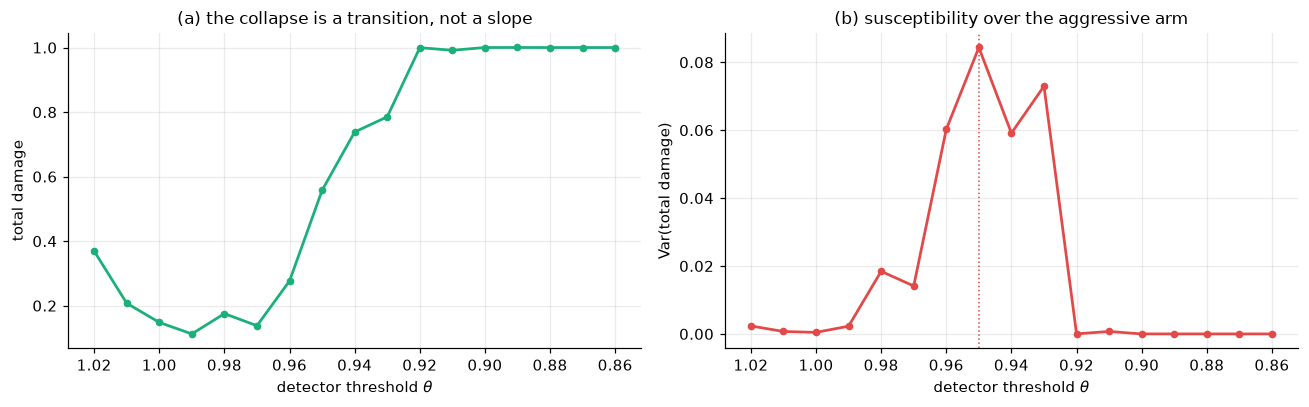

steepest step: damage 0.557 -> 0.277 as theta moves 0.95 -> 0.96
  a 50% change in damage for a 0.01 change in threshold
susceptibility peak (estimated critical sensitivity): theta = 0.95


In [10]:
# H2: is the aggressive arm a genuine transition, or a smooth deterioration?
fine = np.arange(0.86, 1.02, 0.01)
r2 = sweep_theta(fine, alpha=0.6, replicates=12, steps=150,
                 width=50, height=50, noise=0.03, fault_rate=2e-4, seed=7)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 3.8))

ax = axes[0]
ax.plot(fine, r2["total_damage"], marker="o", ms=4,
        color=COLOURS["lattice"], lw=1.8)
ax.set_xlabel(r"detector threshold $\theta$")
ax.set_ylabel("total damage")
ax.set_title("(a) the collapse is a transition, not a slope")
ax.invert_xaxis()

ax = axes[1]
ax.plot(fine, r2["susceptibility"], marker="o", ms=4,
        color=COLOURS["false_positive"], lw=1.8)
theta_star = critical_point(fine, r2["susceptibility"])
ax.axvline(theta_star, color=COLOURS["false_positive"], ls=":", lw=1)
ax.set_xlabel(r"detector threshold $\theta$")
ax.set_ylabel("Var(total damage)")
ax.set_title("(b) susceptibility over the aggressive arm")
ax.invert_xaxis()

plt.tight_layout(); plt.show()

d = r2["total_damage"]
jump = int(np.argmax(np.abs(np.diff(d))))
print(f"steepest step: damage {d[jump]:.3f} -> {d[jump+1]:.3f} "
      f"as theta moves {fine[jump]:.2f} -> {fine[jump+1]:.2f}")
print(f"  a {abs(d[jump+1]-d[jump]) / max(d[jump], 1e-9):.0%} change in damage "
      f"for a {abs(fine[jump+1]-fine[jump]):.2f} change in threshold")
print(f"susceptibility peak (estimated critical sensitivity): "
      f"theta = {theta_star:.2f}")

Both axes are reversed so the detector becomes **more aggressive to the
right**, which is the direction an operator would actually move it while tuning.

*(a)* Damage does not drift upward. It holds low, then jumps. A small tightening
of the threshold the kind of adjustment someone might make to catch a few more
real faults moves the platform from mostly fine to entirely destroyed.

*(b)* Restricted to this arm, susceptibility peaks at the transition, which is
what gives a numerical estimate of the critical sensitivity rather than one read
off by eye.

That is **H2**: the remediation system has a critical sensitivity of its own,
and it is supercritical beyond it. The practical reading is uncomfortable. An
operator tuning a threshold downward sees no warning damage stays low right up
until the platform is gone, so there is no gradual degradation to notice and
back away from.

## 8. What this notebook establishes

| Result | Status |
|---|---|
| The model is a cellular automaton: lattice, finite states, uniform local rule, synchronous update | stated, with the rule shown operating |
| Load is conserved by redistribution | verified |
| Overload threshold $\alpha_c = 1/\lvert N\rvert$ | validated, von Neumann and Moore |
| Detector threshold $\theta_c = (1 + 1/\lvert N\rvert)/(1+\alpha)$ | validated across 2 neighbourhoods × 4 capacities |
| Remediation alone destroys a subcritical platform | demonstrated |
| Damage is U-shaped in sensitivity, with an interior minimum | **H1 supported** |
| The left arm is a sharp transition, not a slope | **H2 supported** |
| Lattice outcomes are bimodal nothing or everything | measured |

The analytic result worth carrying into the report is
$\theta_c = (1 + 1/|N|)/(1+\alpha)$. It says the safe operating point for an
automated remediation system is determined by **how much spare capacity the
platform has and how its load redistributes** not by how good the detector is.
Detector quality does not appear in it. A platform can make its detector better
and still be destroyed by it.



## Issue #2 validation: load accounting

The experiments above retain the default `legacy` rule. The optional
`serving_neighbours` rule shares load only among neighbours that are HEALTHY or
DEGRADED at the start of the step. Both rules now record dropped load, including
load with no eligible recipient. Current load includes transient cells awaiting
transfer. This check follows a continuing cascade, rather than only its first step.

In [11]:
print(f"{'rule':>20}{'step':>6}{'current':>12}{'dropped':>12}{'total':>12}")
for policy in ("legacy", "serving_neighbours"):
    check = LatticeCA(7, 7, alpha=0.1, redistribution=policy)
    check.seed_failure()
    for t in range(13):
        if t:
            check.step()
        ledger = check.load_accounting()
        total = ledger["current_load"] + ledger["dropped_load"]
        assert np.isclose(total, ledger["initial_load"])
        if t in (0, 1, 2, 12):
            print(f"{policy:>20}{t:>6}{ledger['current_load']:>12.2f}"
                  f"{ledger['dropped_load']:>12.2f}{total:>12.2f}")

print("\nNo-neighbour check:")
for policy in ("legacy", "serving_neighbours"):
    isolated = LatticeCA(1, 1, redistribution=policy)
    isolated.seed_failure()
    isolated.run_for(3)
    assert isolated.load.sum() == 0 and isolated.dropped_load == 1
    print(f"{policy}: current=0, dropped=1, initial=1")

                rule  step     current     dropped       total
              legacy     0       49.00        0.00       49.00
              legacy     1       49.00        0.00       49.00
              legacy     2       47.75        1.25       49.00
              legacy    12        0.00       49.00       49.00
  serving_neighbours     0       49.00        0.00       49.00
  serving_neighbours     1       49.00        0.00       49.00
  serving_neighbours     2       49.00        0.00       49.00
  serving_neighbours    12        0.00       49.00       49.00

No-neighbour check:
legacy: current=0, dropped=1, initial=1
serving_neighbours: current=0, dropped=1, initial=1


At step 2, the legacy rule retains 47.75 units and records 1.25 as dropped;
the serving-neighbour rule retains all 49. After all cells exit and transfers
finish, both record all 49 as dropped. The fix makes loss explicit; it does not
promise that every load can always be served.